In [1]:
import time
import cProfile
import pstats
import numpy as np
import matplotlib.pyplot as plt

limite_global = 100000

In [2]:
def primo_mal_optimizado(numero_a_evaluar):
    if numero_a_evaluar == 0 or numero_a_evaluar == 1: return False
    lista_de_divisores = []
    for posible_divisor in range(1, numero_a_evaluar + 1):
        if numero_a_evaluar % posible_divisor == 0:
            lista_de_divisores.append(posible_divisor)
            
    cantidad_de_divisores = 0
    for elemento in lista_de_divisores: cantidad_de_divisores += 1
    return cantidad_de_divisores == 2

def buscar_primos(limite_superior):
    numeros_primos_encontrados = []
    for numero_actual in range(1, limite_superior + 1):
        if primo_mal_optimizado(numero_actual):
            numeros_primos_encontrados.append(numero_actual)
    return numeros_primos_encontrados


t_inicio = time.time()
primos_original = buscar_primos(limite_global)

tiempo_original = time.time() - t_inicio 

print(f"Total de números primos encontrados: {len(primos_original)}")
print(f"Tiempo de ejecución original: {tiempo_original:.6f} segundos.")

Total de números primos encontrados: 9592
Tiempo de ejecución original: 261.335513 segundos.


In [3]:
def buscar_primos_optimizado(limite):
    if limite< 2: return []
    es_primo =np.ones(limite + 1,dtype=bool)
    es_primo[0:2] =False
    
    raiz_cuadrada= int(np.sqrt(limite))
    for numero in range(2, raiz_cuadrada + 1):
        if es_primo[numero]:
            es_primo[numero*numero :limite+1 :numero] = False
            
    return np.nonzero(es_primo) [0].tolist()


t_inicio = time.time()
primos_optimizados = buscar_primos_optimizado(limite_global)

tiempo_optimizado = time.time() - t_inicio 

print(f"Total de números primos encontrados: {len(primos_optimizados)}")
print(f"Tiempo de ejecución optimizado: {tiempo_optimizado:.6f} segundos.")

Total de números primos encontrados: 9592
Tiempo de ejecución optimizado: 0.000000 segundos.


Se crea profiling_optimizado.txt


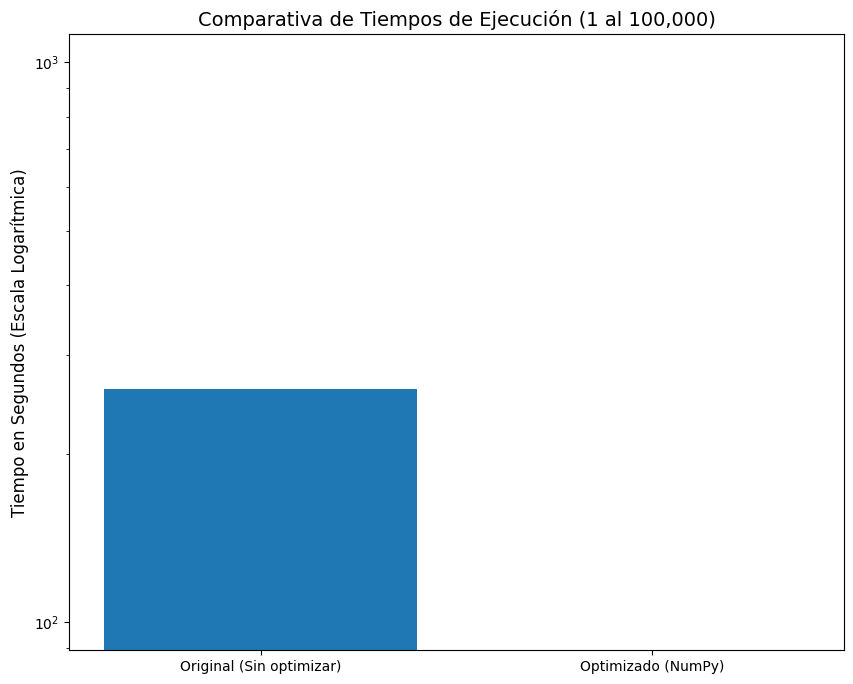

In [ ]:

print("Se crea profiling_optimizado.txt")
profiler = cProfile.Profile()
profiler.enable()
buscar_primos_optimizado(limite_global)
profiler.disable()

with open("profiling_optimizado.txt", "w") as f:
    stats = pstats.Stats(profiler, stream=f)
    stats.strip_dirs()
    stats.sort_stats('tottime')
    stats.print_stats()

# Gráficos 
nombres = ['Original (Sin optimizar)', 'Optimizado (NumPy)']
tiempos = [tiempo_original, tiempo_optimizado]

fig, ax = plt.subplots(figsize=(10,8))
barras = ax.bar(nombres, tiempos)

ax.set_title('Comparativa de Tiempos de Ejecución (1 al 100,000)', fontsize=14)
ax.set_ylabel('Tiempo en Segundos (Escala Logarítmica)', fontsize=12)


plt.yscale('log') # Se usa logaritmos para que se pueda ver bien la gráfica
plt.savefig('grafico_tiempos.png')
plt.show()